## One cycle Emotion


In [1]:
import numpy as np
from tqdm import tqdm
from typing import List
import math,copy,os,random
#from google.colab import drive
from collections import Counter
import matplotlib.pyplot as plt

#PyTorch stuff
import torch
from torch import optim, nn
from torch import amp
from torch.nn import Parameter
from torchvision import datasets
from torch.nn import functional as F
from torchvision.transforms import v2
from torch.nn.utils import clip_grad_norm_
from torchvision.ops import stochastic_depth
from torch.utils.data import DataLoader,Subset
from torchvision.transforms.functional import InterpolationMode

### GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
scaler = amp.GradScaler()

C:\Users\CJ\AppData\Local\Temp\ipykernel_1836\1051404655.py:1: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = amp.GradScaler()


In [5]:
!mkdir zipfile

In [6]:
!cp /content/drive/MyDrive/dataset/dataset.zip /content/zipfile/dataset.zip

In [7]:
!mkdir dataset
!cp -r /content/zipfile/dataset.zip /content/dataset/dataset.zip
!unzip dataset/dataset.zip -d dataset
!rm -rf dataset/dataset.zip

Archive:  dataset/dataset.zip
  inflating: dataset/angry.zip       
  inflating: dataset/disgust.zip     
  inflating: dataset/fear.zip        
  inflating: dataset/happy.zip       
  inflating: dataset/sad.zip         
  inflating: dataset/surprise.zip    


In [8]:
!mkdir dataset/angry
!mkdir dataset/disgust
!mkdir dataset/fear
!mkdir dataset/happy
!mkdir dataset/sad
!mkdir dataset/surprise

In [9]:
!mv dataset/angry.zip dataset/angry/angry.zip
!mv dataset/disgust.zip dataset/disgust/disgust.zip
!mv dataset/fear.zip dataset/fear/fear.zip
!mv dataset/happy.zip dataset/happy/happy.zip
!mv dataset/sad.zip dataset/sad/sad.zip
!mv dataset/surprise.zip dataset/surprise/surprise.zip

In [10]:
!unzip dataset/angry/angry.zip -d dataset/angry
!unzip dataset/disgust/disgust.zip -d dataset/disgust
!unzip dataset/fear/fear.zip -d dataset/fear
!unzip dataset/happy/happy.zip -d dataset/happy
!unzip dataset/sad/sad.zip -d dataset/sad
!unzip dataset/surprise/surprise.zip -d dataset/surprise

Streaming output truncated to the last 5000 lines.
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113315.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113318.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113320.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113323.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113326.png  
  inflating: dataset/surprise/Captura de pantalla 2024-08-11 113328.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113331.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113334.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113336.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113338.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113343.png  
 extracting: dataset/surprise/Captura de pantalla 2024-08-11 113345.png  
  inflating: dataset/surprise/Captura de pantalla 2024-08-11 

In [11]:
!rm -rf dataset/angry/angry.zip
!rm -rf dataset/disgust/disgust.zip
!rm -rf ataset/fear/fear.zip
!rm -rf dataset/happy/happy.zip
!rm -rf dataset/sad/sad.zip
!rm -rf val/surprise/surprise.zip

###  Datasets y Dataloaders

In [4]:
#PATH = "/content/dataset"
PATH = r"X:\CJ\Dataset\emotion\Dataset\full_set_128\raw"

mean = 0.4299136
std = 0.2605381


train_transforms = v2.Compose([
                  v2.Resize((128, 128), antialias=True),
                  v2.Grayscale(num_output_channels=1),

                  v2.RandomHorizontalFlip(p=0.5),
                  v2.RandomApply([v2.RandomRotation(10, interpolation=InterpolationMode.BICUBIC, fill= int(mean * 255))],p=0.4),
                  v2.RandomApply([v2.RandomResizedCrop(128, scale=(0.9, 1.0), ratio=(1.0, 1.0),interpolation=v2.InterpolationMode.BICUBIC)], p=0.3),
                  v2.RandomApply([v2.RandomAffine(degrees=0, translate=(0.05,0.05),interpolation=v2.InterpolationMode.BICUBIC,fill=int(mean * 255))],p=0.3),

                  v2.RandomApply([v2.ColorJitter(0.1, 0.1)],p=0.4),
                  v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.2, 1.0))], p=0.05),

                  v2.ToImage(),
                  v2.ToDtype(torch.float32, scale=True),
                  v2.Normalize([mean], [std]),
                  v2.RandomErasing(p=0.05, scale=(0.01, 0.03), ratio=(0.4, 0.8))
            ])
val_test_transforms = v2.Compose([
                    v2.Resize((128, 128), antialias=True),
                    v2.Grayscale(num_output_channels=1),
                    v2.ToImage(),
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize([mean], [std])
            ])

In [5]:
SEED = 20000807
def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

base_dataset = datasets.ImageFolder(PATH)

class_indices = {cls_idx: [] for cls_idx in range(len(base_dataset.classes))}
for idx, (_, label) in enumerate(base_dataset.samples):
    class_indices[label].append(idx)

train_idx, val_idx, test_idx = [], [], []
train_ratio, val_ratio = 0.8, 0.1

for cls, idxs in class_indices.items():
    rng = np.random.default_rng(SEED + cls)
    idxs = rng.permutation(idxs)

    n_total = len(idxs)
    n_test = int(0.1 * n_total)
    n_val = int(0.1 * n_total)
    n_train = n_total - n_test - n_val

    test_idx.extend(idxs[:n_test])
    val_idx.extend(idxs[n_test:n_test + n_val])
    train_idx.extend(idxs[n_test + n_val:])

train_if = datasets.ImageFolder(PATH, transform=train_transforms)
val_if   = datasets.ImageFolder(PATH, transform=val_test_transforms)
test_if  = datasets.ImageFolder(PATH, transform=val_test_transforms)

train_dataset = Subset(train_if, train_idx)
val_dataset   = Subset(val_if, val_idx)
test_dataset  = Subset(test_if, test_idx)

g = torch.Generator()
g.manual_seed(SEED)

def _worker_init_fn(worker_id):
    s = SEED + worker_id
    np.random.seed(s)
    random.seed(s)

bs = 160
nw = 0

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True,
                          num_workers=nw, pin_memory=True, drop_last=False,
                          worker_init_fn=_worker_init_fn, generator=g)

val_loader   = DataLoader(val_dataset, batch_size=bs, shuffle=False,
                          num_workers=nw, pin_memory=True, drop_last=False,
                          worker_init_fn=_worker_init_fn, generator=g)

test_loader  = DataLoader(test_dataset, batch_size=bs, shuffle=False,
                          num_workers=nw, pin_memory=True, drop_last=False,
                          worker_init_fn=_worker_init_fn, generator=g)


In [6]:
def count_per_class(subset, name):
    labels = [subset.dataset.samples[i][1] for i in subset.indices]
    c = Counter(labels)
    print(f"\n{name.upper()}")
    for cls_idx, cls_name in enumerate(subset.dataset.classes):
        print(f"  {cls_name}: {c[cls_idx]} imágenes")

count_per_class(train_dataset, "train")
count_per_class(val_dataset, "val")
count_per_class(test_dataset, "test")


TRAIN
  angry: 5200 imágenes
  disgust: 5200 imágenes
  fear: 5200 imágenes
  happy: 5200 imágenes
  sad: 5200 imágenes
  surprise: 5200 imágenes

VAL
  angry: 650 imágenes
  disgust: 650 imágenes
  fear: 650 imágenes
  happy: 650 imágenes
  sad: 650 imágenes
  surprise: 650 imágenes

TEST
  angry: 650 imágenes
  disgust: 650 imágenes
  fear: 650 imágenes
  happy: 650 imágenes
  sad: 650 imágenes
  surprise: 650 imágenes


In [7]:
for i,(x, y) in enumerate(test_loader):
    print(i, x.shape, y.shape)

x:\CJ\Documents\trabajo de grado\thesis\emotion\source\notebook\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0 torch.Size([160, 1, 128, 128]) torch.Size([160])
1 torch.Size([160, 1, 128, 128]) torch.Size([160])
2 torch.Size([160, 1, 128, 128]) torch.Size([160])
3 torch.Size([160, 1, 128, 128]) torch.Size([160])
4 torch.Size([160, 1, 128, 128]) torch.Size([160])
5 torch.Size([160, 1, 128, 128]) torch.Size([160])
6 torch.Size([160, 1, 128, 128]) torch.Size([160])
7 torch.Size([160, 1, 128, 128]) torch.Size([160])
8 torch.Size([160, 1, 128, 128]) torch.Size([160])
9 torch.Size([160, 1, 128, 128]) torch.Size([160])
10 torch.Size([160, 1, 128, 128]) torch.Size([160])
11 torch.Size([160, 1, 128, 128]) torch.Size([160])
12 torch.Size([160, 1, 128, 128]) torch.Size([160])
13 torch.Size([160, 1, 128, 128]) torch.Size([160])
14 torch.Size([160, 1, 128, 128]) torch.Size([160])
15 torch.Size([160, 1, 128, 128]) torch.Size([160])
16 torch.Size([160, 1, 128, 128]) torch.Size([160])
17 torch.Size([160, 1, 128, 128]) torch.Size([160])
18 torch.Size([160, 1, 128, 128]) torch.Size([160])
19 torch.Size([160, 1,

### Mostrar datos

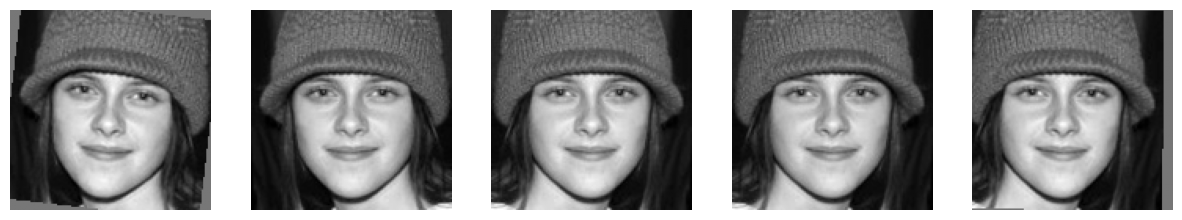

In [14]:
idx = np.random.randint(0, len(train_loader.dataset))
fig, axs = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    img, lab = train_loader.dataset[idx]  # <-- mismo idx, debería salir distinta cada vez
    img_show = img.clone()
    # des-normaliza sólo para ver (opcional):
    img_show = img_show * std + mean
    img_show = img_show.clamp(0,1)
    axs[i].imshow(img_show.squeeze(), cmap='gray')
    axs[i].axis('off')
plt.show()


La imagen muestreada representa un: sad


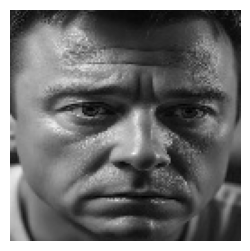

In [22]:
classes = train_dataset.dataset.classes
def plot_figure(image):
    plt.figure(figsize=(3,3))
    plt.imshow(image.squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

rnd_sample_idx = np.random.randint(len(test_loader.dataset))
print(f'La imagen muestreada representa un: {classes[test_loader.dataset[rnd_sample_idx][1]]}')
image = test_loader.dataset[rnd_sample_idx][0]
image = (image - image.min()) / (image.max() -image.min() )
plot_figure(image)

#### Accuracy

In [7]:
def accuracy(model, loader):
    model.eval()
    total, correct, cost = 0, 0, 0.0

    with torch.no_grad(), amp.autocast('cuda'):
        for x, y in loader:
            x = x.to(device, dtype=torch.float32, non_blocking=True)
            y = y.to(device, dtype=torch.long, non_blocking=True)

            scores = model(x)
            cost += F.cross_entropy(scores, y, reduction='sum').item()

            pred = scores.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    avg_loss = cost / total
    acc = correct / total
    return avg_loss, acc


#### Buscar learning rate

In [ ]:
def find_lr(model,optimiser,loader=train_loader,start_val=1e-6,end_val=3e-1,beta=0.99,max_iters=400):
    model = model.to(device)
    model.train()

    # --- backup ArcFace + modelo/opt ---
    m_backup = float(model.a_f.m)
    s_backup = float(model.a_f.s)
    cfg_backup = copy.deepcopy(getattr(model.a_f, "_sched_cfg", None))
    model_state = copy.deepcopy(model.state_dict())
    opt_state   = copy.deepcopy(optimiser.state_dict())

    # --- fija geometría razonable para el sweep ---
    model.a_f.m = 0.20          # <- más suave que 0.30
    model.a_f.s = 20.0
    model.a_f._update_constants()
    model.a_f._sched_cfg = None  # desactiva cualquier schedule

    # --- LR geométrico ---
    n_steps = min(max_iters, max(1, len(loader) - 1))
    factor = (end_val / start_val) ** (1 / n_steps)
    lr = start_val
    for g in optimiser.param_groups:
        g['lr'] = start_val

    avg_loss = 0.0; loss_ema = 0.0
    avg_acc  = 0.0; acc_ema  = 0.0
    lowest_loss = float('inf')

    lrs, losses, accuracies = [], [], []

    iters = 0
    for x, y in loader:
        iters += 1
        x = x.to(device, dtype=torch.float32, non_blocking=True)
        y = y.to(device, dtype=torch.long, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)

        with amp.autocast('cuda'):
            scores = model(x, labels=y)
            loss = F.cross_entropy(scores, y)

        # EMA
        loss_ema = beta * loss_ema + (1 - beta) * loss.item()
        avg_loss = loss_ema / (1 - beta ** iters)

        acc_batch = (scores.argmax(1) == y).float().mean().item()
        acc_ema = beta * acc_ema + (1 - beta) * acc_batch
        avg_acc = acc_ema / (1 - beta ** iters)

        lowest_loss = min(lowest_loss, avg_loss)
        if iters > 10 and (math.isnan(avg_loss) or avg_loss > 4 * lowest_loss):
            print(f"[LR Finder] Stop @ iter {iters}, loss~={avg_loss:.4f}")
            break

        loss.backward()
        optimiser.step()

        # log
        lrs.append(lr)
        losses.append(avg_loss)
        accuracies.append(avg_acc)
        print(f'iter:{iters:3d}  cost:{loss.item():.4f}  lr:{lr:.6f}  acc:{acc_batch:.4f}')

        # next lr
        lr *= factor
        for g in optimiser.param_groups:
            g['lr'] = lr

        if iters >= n_steps:
            break

    # --- restore  ---
    model.load_state_dict(model_state)
    optimiser.load_state_dict(opt_state)
    model.a_f.m = m_backup
    model.a_f.s = s_backup
    model.a_f._sched_cfg = cfg_backup
    model.a_f._update_constants()

    return lrs, losses, accuracies


### Loop de Entrenamiento

In [8]:
def train(model, optimiser, scheduler=None, epochs=100):
    model = model.to(device)
    val_loss_history = []
    train_loss_history = []
    val_acc_history = []
    train_acc_history = []
    lrs = []
    best_acc = -1.0
    best_path = "best.pt"


    model.a_f.configure_schedule(total_epochs=epochs, use_fixed_schedule=True)

    for epoch in range(epochs):
        train_correct_num = 0
        train_total = 0
        train_cost_acum = 0
        train_count   = 0

        #Arcface gradual margin
        model.a_f.set_margin(epoch)
        model.a_f.set_scale(epoch)

        #Label smoothing
        eps = 0.05 if epoch <= 49 else (0.0 if epoch >= 80 else 0.02)

        model.train()

        for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
            x = x.to(device, dtype=torch.float32)
            y = y.to(device, dtype=torch.long)
            optimiser.zero_grad(set_to_none=True)
            with amp.autocast('cuda'):
              #Arcface logits
              scores = model(x,labels=y)

              if eps>0:
                  cost = F.cross_entropy(scores, y, label_smoothing=eps)
              else:
                cost = F.cross_entropy(scores, y)

            #cost.backward()
            #optimiser.step()
            scaler.scale(cost).backward()
            scaler.unscale_(optimiser)

            if epoch < 3:
                max_norm = 2
            else:
                max_norm = 5

            clip_grad_norm_(model.parameters(),max_norm)
            scaler.step(optimiser)
            scaler.update()

            if scheduler:
                scheduler.step()

            # Acumular métricas de entrenamiento
            bs = y.size(0)

            train_correct_num += (torch.argmax(scores, dim=1) == y).sum().item()
            train_total += bs
            train_cost_acum += cost.item() * bs
            train_count += bs

            # Guardar LR por minibatch
            lrs.append(optimiser.param_groups[0]["lr"])

        # Métricas promedio por epoch
        train_acc = train_correct_num / train_total
        train_cost = train_cost_acum / train_count
        train_loss_history.append(train_cost)
        train_acc_history.append(train_acc)

        # Validación solo una vez por epoch
        val_cost, val_acc = accuracy(model, val_loader)
        val_loss_history.append(val_cost)
        val_acc_history.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({"model": model.state_dict(),
                        "epoch": epoch,
                        "val_acc": val_acc}, best_path)
            print(f"[BEST] epoch={epoch} val_acc={val_acc:.4f}")

        print(f"Epoch {epoch}: train_cost={train_cost:.6f}, val_cost={val_cost:.6f}, "
              f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}, lr={optimiser.param_groups[0]['lr']:.6f}")

    return train_loss_history, val_loss_history, train_acc_history, val_acc_history, lrs


### Residual Block

In [9]:
conv_k_3 = lambda channel1, channel2, stride: nn.Conv2d(channel1, channel2, stride = stride, kernel_size=3, padding=1, bias=False)

In [10]:
class residual_block(nn.Module):
    '''

    '''
    def __init__(self, in_channel, out_channel, stride=1, change_size = True, activation= F.relu, dpp=0.0):
        super().__init__()
        self.conv1 = conv_k_3(in_channel, out_channel, stride)
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.conv2 = conv_k_3(out_channel, out_channel, 1)
        self.bn2 = nn.BatchNorm2d(out_channel)
        #for changing activation map sizes
        self.change_size = change_size
        self.f = activation
        if change_size:
            self.residual = nn.Sequential(nn.Conv2d(in_channel,
                                                    out_channel,
                                                    kernel_size=1,
                                                    stride=stride,
                                                    bias=False),
                                         nn.BatchNorm2d(out_channel)
                                         )
        self.drop_path_prob = float(dpp)
        if hasattr(self.bn2, 'weight'):
          nn.init.constant_(self.bn2.weight, 0.0)

    def forward(self, x):
        identity = x if not self.change_size else self.residual(x)
        y = self.f(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        if self.training:
          y = stochastic_depth(y,p=self.drop_path_prob, mode='row',training=self.training)
        y += identity
        return self.f(y)


### DroPathController

In [11]:
class DropPathController:
    """
    Genera probabilidades de DropPath crecientes con la profundidad.
    next_p() devuelve la p del bloque actual y avanza el cursor.
    """

    def __init__(self, total_blocks: int, p_max: float = 0.1, mode: str = 'linear',
                 single_block_at_max: bool = False, clamp: bool = True):
        if total_blocks < 1:
            raise ValueError("total_blocks debe ser >= 1")
        if not (0.0 <= p_max <= 1.0):
            raise ValueError("p_max debe estar en [0, 1]")
        mode = mode.lower()
        if mode not in ('linear', 'quadratic', 'cosine'):
            raise ValueError(f"Modo desconocido: {mode}")

        self.total_blocks = int(total_blocks)
        self.p_max = float(p_max)
        self.mode = mode
        self.single_block_at_max = bool(single_block_at_max)
        self.clamp = bool(clamp)
        self.idx = 0

    def __len__(self) -> int:
        return self.total_blocks

    def reset(self) -> None:
        self.idx = 0

    def _shape(self, t: float) -> float:
        if self.mode == 'linear':
            return t
        elif self.mode == 'quadratic':
            return t * t
        else:  # 'cosine'
            return 1.0 - math.cos(t * math.pi / 2.0)

    def get_p(self, i: int) -> float:
        if self.total_blocks == 1:
            return self.p_max if self.single_block_at_max else 0.0

        denom = float(self.total_blocks - 1)
        t = i / denom
        if self.clamp:
            t = max(0.0, min(1.0, t))
        return self.p_max * self._shape(t)

    def peek(self) -> float:
        return self.get_p(self.idx)

    def next_p(self) -> float:
        p = self.get_p(self.idx)
        if self.idx < self.total_blocks:  # evita overflow silencioso
            self.idx += 1
        elif not self.clamp:
            # si clamp=False y te pasas, lanza error claro
            raise IndexError("next_p() llamado más veces que total_blocks")
        return p

    def as_list(self) -> List[float]:
        return [self.get_p(i) for i in range(self.total_blocks)]


### Arcface

In [12]:
class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features,
                 s=10.0,
                 m=0.35,
                 easy_margin=False,
                 warmup_epochs=15):          # <- mucho más corto
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.s = float(s)
        self.m_max = float(m)
        self.m = 0.10                     # marg. inicial
        self.warmup_epochs = int(warmup_epochs)
        self.easy_margin = easy_margin

        self.weight = Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self._update_constants()
        self._sched_cfg = None

    # --------- NUEVA CONFIG ---------
    def configure_schedule(self,
                           total_epochs=100,
                           use_fixed_schedule=True,
                           # b0: hasta aquí subimos suave
                           boundaries=10,
                           # márgenes
                           m0=0.10,
                           m_mid=0.24,
                           m_max=0.30,
                           # escalas
                           s_start=10.0,
                           s_final=25.0):
        self._sched_cfg = dict(
            total_epochs=int(total_epochs),
            use_fixed_schedule=bool(use_fixed_schedule),
            b0=int(boundaries),
            m0=float(m0),
            m_mid=float(m_mid),
            m_max=float(m_max),
            s_start=float(s_start),
            s_final=float(s_final),
            post_ramp=5,   # tramo corto final
        )

    def _ms_from_epoch(self, epoch: int):
        cfg = getattr(self, "_sched_cfg", None)
        if not cfg or not cfg["use_fixed_schedule"]:
            # fallback lineal corto
            t = min(epoch / max(1, self.warmup_epochs), 1.0)
            m = 0.10 + t * (self.m_max - 0.10)
            s = 10.0 + t * (20.0 - 10.0)
            return float(m), float(s)

        b0   = cfg["b0"]
        m0   = cfg["m0"]
        m_mid= cfg["m_mid"]
        m_max= cfg["m_max"]
        s_start = cfg["s_start"]
        s_final = cfg["s_final"]
        post    = cfg["post_ramp"]

        # ----- margen -----
        if epoch <= b0:
            # 0..b0: m0 -> m_mid
            t = epoch / max(1, b0)
            m = m0 + (m_mid - m0) * t
        else:
            # b0..b0+post: m_mid -> m_max
            t = min(max(epoch - b0, 0) / max(1, post), 1.0)
            m = m_mid + (m_max - m_mid) * t

        # ----- escala -----
        if epoch <= b0:
            t = epoch / max(1, b0)
            s = s_start + (s_final - s_start) * t
        else:
            s = s_final

        return float(m), float(s)

    def _update_constants(self):
        self.cos_m = math.cos(self.m)
        self.sin_m = math.sin(self.m)
        self.th = math.cos(math.pi - self.m)
        self.mm = math.sin(math.pi - self.m) * self.m

    def set_margin(self, epoch: int):
        m, _ = self._ms_from_epoch(epoch)
        self.m = float(m)
        self._update_constants()

    def set_scale(self, epoch: int):
        _, s = self._ms_from_epoch(epoch)
        self.s = float(s)

    def forward(self, input, label):
        # cos(theta)
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - cosine ** 2).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)

        # aplica el margen solo a la clase verdadera
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        # y luego escala
        output *= self.s
        return output


### ResNet56

In [13]:
class ResNet56(nn.Module):
    def __init__(self, n=9, num_classes=6):
        super().__init__()

        total_blocks = 2*n
        self.dp = DropPathController(total_blocks, p_max=0.05, mode='linear')

        self.conv1 = conv_k_3(1, 32, stride=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.block1 = self.create_block(n=9, in_channel=32,
                                        out_channel=64, stride=2)

        self.block2 = self.create_block(n=9, in_channel=64,
                                        out_channel=128, stride=2, dp=True)

        self.block3 = self.create_block(n=9, in_channel=128,
                                        out_channel=256, stride=2, activation=F.silu,dp=True)

        self.f_e = residual_block(256, 128, stride=2, change_size=True, activation=F.silu)

        self.flatten = nn.Flatten()

        self.dense1 = nn.Linear(8*8*128,512,bias=False)
        self.bn2 = nn.BatchNorm1d(512)
        #self.ln = nn.LayerNorm(512, elementwise_affine=True)

        self.a_f = ArcMarginProduct(in_features=512, out_features=num_classes, easy_margin=False)


    def create_block(self, n, in_channel, out_channel, stride, change_size=True, activation=F.relu,dp=False):
        block = [residual_block(in_channel, out_channel, stride, change_size=change_size, activation=activation,dpp=self.dp.next_p() if dp else 0.0)]
        for i in range(n-1):
            block.append(residual_block(out_channel, out_channel, stride=1, change_size=False, activation=activation,dpp=self.dp.next_p() if dp else 0.0))
        return nn.Sequential(*block)

    def forward(self, x, return_emb=False, r_n_emb=False, FE = False, labels=None):

        y = F.relu(self.bn1(self.conv1(x)))
        y = self.block1(y)
        y = self.block2(y)
        y = self.block3(y)
        y = self.f_e(y)

        if FE:
           return y

        y = self.flatten(y)
        y = self.dense1(y)

        if return_emb:
          return y

        if r_n_emb:
          return F.normalize(y.float(), dim=1, eps=1e-4)

        y = self.bn2(y)

        with amp.autocast('cuda',enabled=False):
            y = y.float()
            if labels is not None:
              return self.a_f(y,labels)

            else:
              logits = F.linear(F.normalize(y, dim=1, eps=1e-4), F.normalize(self.a_f.weight.float(), dim=1, eps=1e-4))
              logits = logits * self.a_f.s
            return logits 

### Parametros

In [14]:
def build_param_groups(model, wd=5e-4):
    wd_params = []
    head_params_wd = []
    no_wd_params = []
    af_params = []
    no_wd_ids = set()

    # Normalizadores SIN WD
    NORM_TYPES = (
        nn.BatchNorm1d, nn.BatchNorm2d, nn.SyncBatchNorm,
        nn.LayerNorm, nn.GroupNorm, nn.InstanceNorm1d, nn.InstanceNorm2d
    )

    for m in model.modules():
        if isinstance(m, NORM_TYPES):
            for p in m.parameters(recurse=False):
                if p.requires_grad:
                    no_wd_params.append(p)
                    no_wd_ids.add(id(p))

    # Clasifica por nombre
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        # Biases o normalizadores -> sin WD
        if name.endswith(".bias") or id(p) in no_wd_ids:
            continue

        # ArcFace: sin WD
        if name == "a_f.weight" or name.endswith(".a_f.weight"):
            af_params.append(p)
            continue

        # Head (últimas capas densas): sin WD
        if any(k in name for k in ["dense1"]):
            head_params_wd.append(p)
            continue

        # Resto: backbone con WD
        wd_params.append(p)

    param_groups = []
    if wd_params:
        param_groups.append({"params": wd_params, "weight_decay": wd})
    if head_params_wd:
        param_groups.append({"params": head_params_wd, "weight_decay": 0.0})
    if af_params:
        param_groups.append({"params": af_params, "weight_decay": 0.0})
    if no_wd_params:
        param_groups.append({"params": no_wd_params, "weight_decay": 0.0})

    return param_groups


In [15]:
model_resnet56 = ResNet56()

In [16]:
param_groups = build_param_groups(model_resnet56, wd=1e-4)
# model_resnet56 = ResNet56()
optimiser_resnet56 = torch.optim.SGD(param_groups,lr=0.1, momentum=0.9,nesterov=True, weight_decay=0.0)

In [ ]:
lg_lr, losses, accuracies = find_lr(model_resnet56, optimiser_resnet56,
                                    start_val=1e-4, end_val=1)

iter:  1  cost:5.9073  lr:0.000100  acc:0.0000
iter:  2  cost:5.7689  lr:0.000105  acc:0.0000
iter:  3  cost:5.6729  lr:0.000110  acc:0.0000
iter:  4  cost:5.8133  lr:0.000115  acc:0.0000
iter:  5  cost:5.6363  lr:0.000121  acc:0.0000
iter:  6  cost:5.6486  lr:0.000127  acc:0.0000
iter:  7  cost:5.6382  lr:0.000133  acc:0.0000
iter:  8  cost:5.6490  lr:0.000139  acc:0.0000
iter:  9  cost:5.5423  lr:0.000146  acc:0.0000
iter: 10  cost:5.7635  lr:0.000153  acc:0.0000
iter: 11  cost:5.6959  lr:0.000161  acc:0.0000
iter: 12  cost:5.7573  lr:0.000169  acc:0.0000
iter: 13  cost:5.7048  lr:0.000177  acc:0.0000
iter: 14  cost:5.5828  lr:0.000185  acc:0.0000
iter: 15  cost:5.6114  lr:0.000194  acc:0.0000
iter: 16  cost:5.6437  lr:0.000204  acc:0.0000
iter: 17  cost:5.4780  lr:0.000214  acc:0.0000
iter: 18  cost:5.6102  lr:0.000224  acc:0.0000
iter: 19  cost:5.5737  lr:0.000235  acc:0.0000
iter: 20  cost:5.4936  lr:0.000246  acc:0.0000
iter: 21  cost:5.5360  lr:0.000258  acc:0.0000
iter: 22  cos

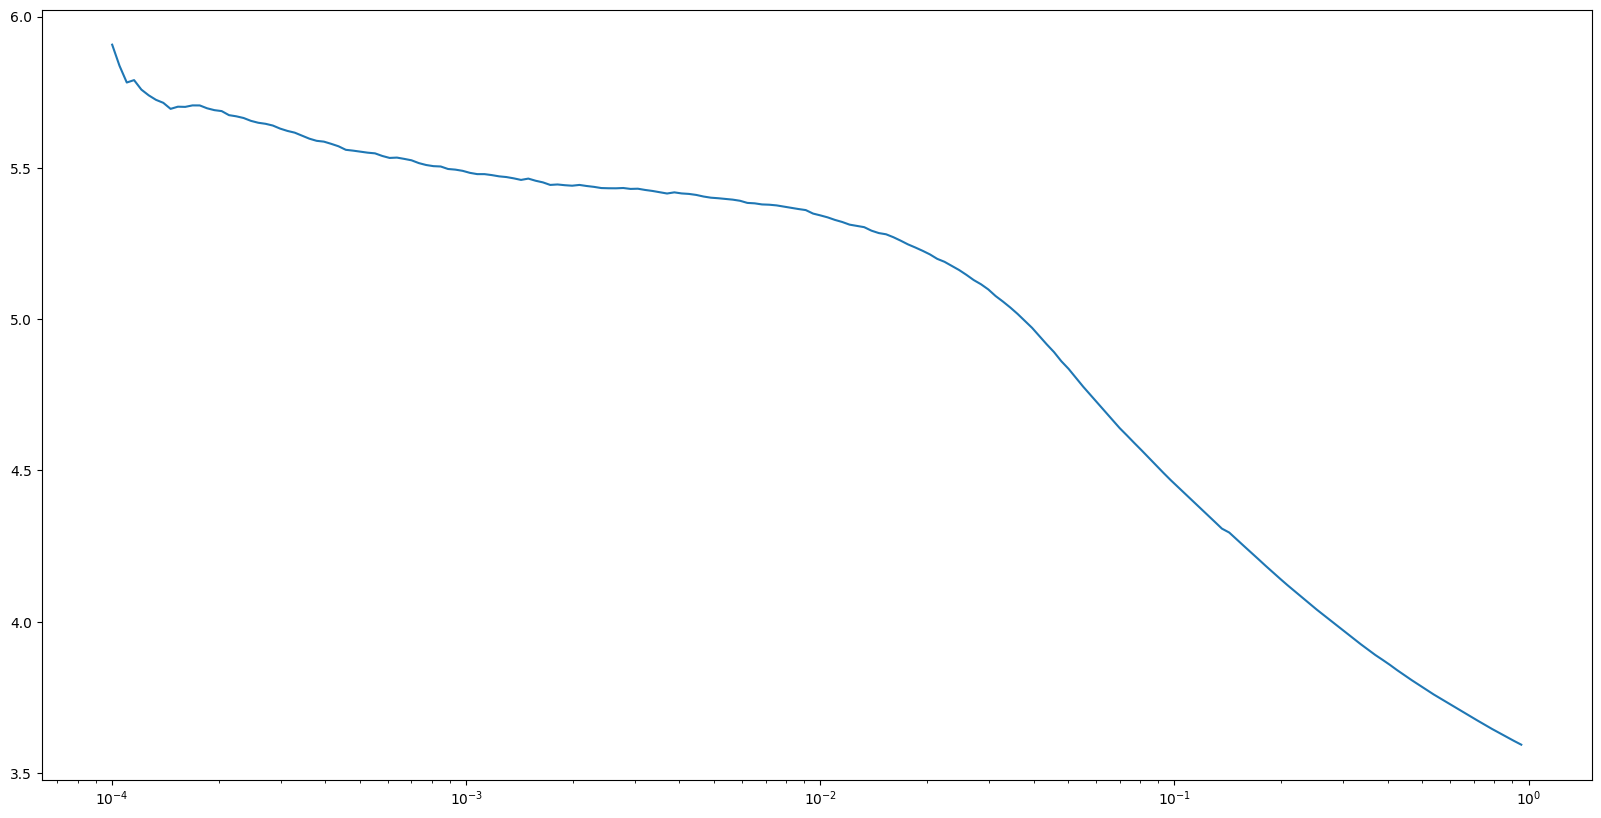

In [ ]:
f1, ax1 = plt.subplots(figsize=(20,10))
# ax1.plot(lr[60:-2], losses[60:-2])
ax1.plot(lg_lr, losses)
ax1.set_xscale('log')
#ax1.set_xticks([1e-6,3e-6, 1])
ax1.get_xaxis().get_major_formatter().labelOnlyBase = False
plt.show()

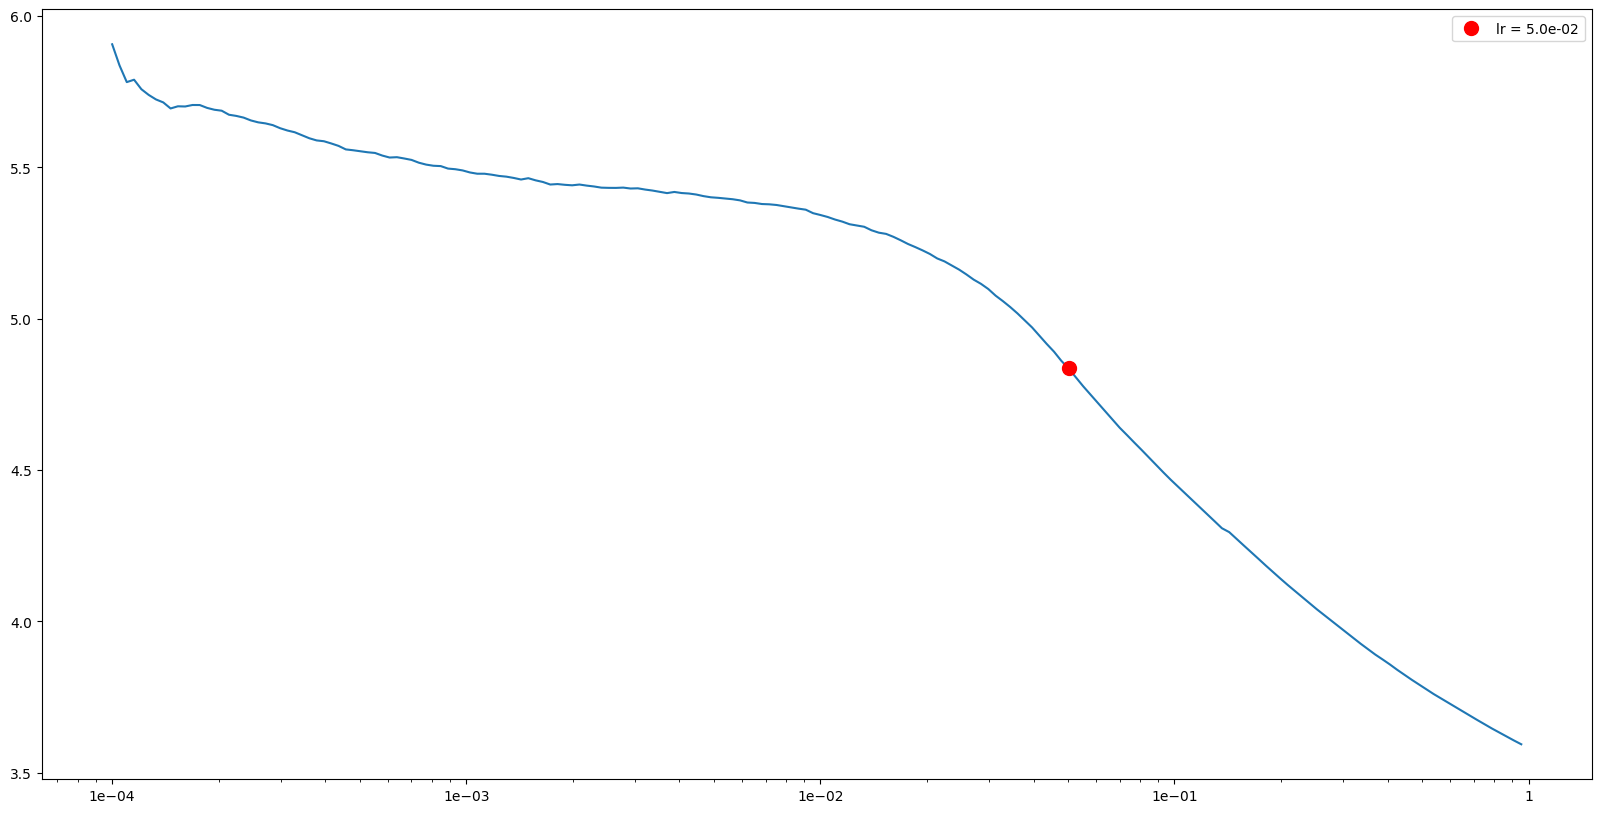

In [ ]:
from matplotlib.ticker import LogFormatter

f1, ax1 = plt.subplots(figsize=(20,10))

ax1.plot(lg_lr, losses)

# Escala logarítmica
ax1.set_xscale('log')

ax1.xaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=False))

# Buscar índice más cercano en lg_lr
lg_lr_array = np.array(lg_lr)   # <-- convertir lista a array
target_lr = 5e-2
idx = (np.abs(lg_lr_array - target_lr)).argmin()

ax1.plot(lg_lr_array[idx], losses[idx], 'ro', markersize=10, label=f'lr = {lg_lr_array[idx]:.1e}')
ax1.legend()


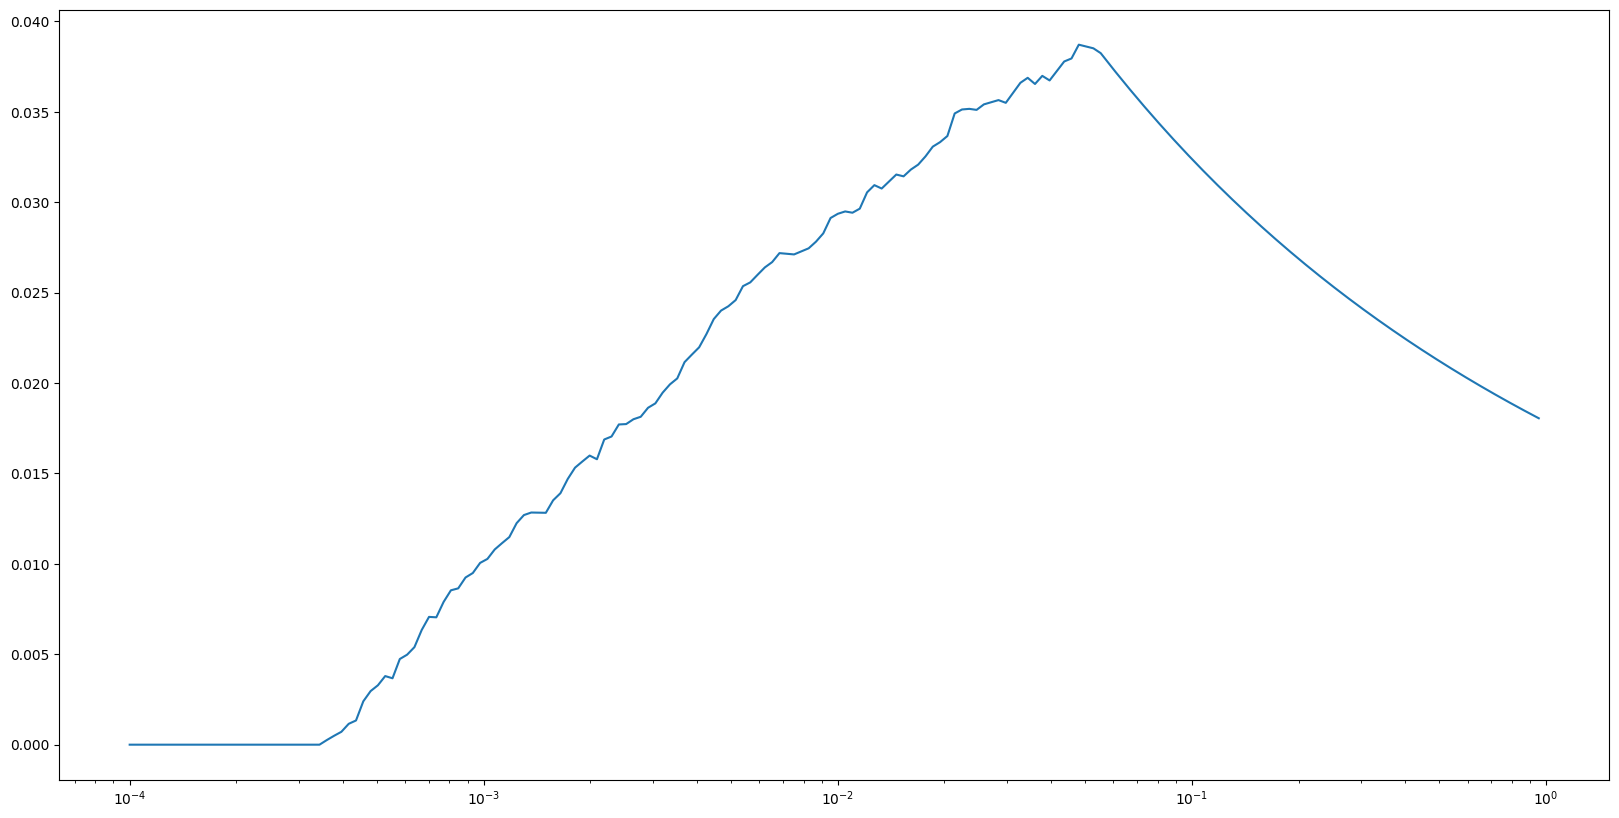

In [ ]:
f1, ax1 = plt.subplots(figsize=(20,10))
# ax1.plot(lr[60:-2], losses[60:-2])
ax1.plot(lg_lr, accuracies)
ax1.set_xscale('log')
# ax1.set_xticks([1e-1, 2e-1,5e-1, 7e-1, 1, 10])
ax1.get_xaxis().get_major_formatter().labelOnlyBase = False
plt.show()

In [ ]:
del losses, accuracies  # las listas pueden ser grandes
torch.cuda.empty_cache()


In [ ]:
del model_resnet56
torch.cuda.empty_cache()


### Training

In [ ]:
target_lr = 5e-2
epochs = 101

model_resnet56 = ResNet56()
param_groups = build_param_groups(model_resnet56, wd=1e-4)
optimiser_resnet56 = torch.optim.SGD(
    param_groups,
    lr=target_lr/25,
    momentum=0.9,
    nesterov=True,
    weight_decay=0.0,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimiser_resnet56,
    max_lr=target_lr,
    steps_per_epoch=len(train_loader),
    epochs=epochs,
    pct_start=0.3,
    div_factor=25,
    final_div_factor=1000,
    anneal_strategy='cos',
    three_phase=False,
    cycle_momentum=True
)

train_loss_history, val_loss_history, train_acc_history, val_acc_history, lrs = train(
                                model_resnet56,
                                optimiser=optimiser_resnet56,
                                scheduler=scheduler,
                                epochs = epochs
                                )

Epoch 0/101: 100%|██████████| 195/195 [02:24<00:00,  1.35it/s]


[BEST] epoch=0 val_acc=0.4149
Epoch 0: train_cost=2.410152, val_cost=1.456681, train_acc=0.1037, val_acc=0.4149, lr=0.002129


Epoch 1/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]


[BEST] epoch=1 val_acc=0.5141
Epoch 1: train_cost=2.367781, val_cost=1.292964, train_acc=0.2010, val_acc=0.5141, lr=0.002514


Epoch 2/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]


...

Epoch 98: train_cost=0.017463, val_cost=0.425873, train_acc=0.9970, val_acc=0.9413, lr=0.000100


Epoch 99/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]


[BEST] epoch=99 val_acc=0.9433
Epoch 99: train_cost=0.010734, val_cost=0.421713, train_acc=0.9978, val_acc=0.9433, lr=0.000026


Epoch 100/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]


Epoch 100: train_cost=0.014453, val_cost=0.425708, train_acc=0.9970, val_acc=0.9426, lr=0.000002


In [ ]:
path_save = "/content/drive/MyDrive/dataset/modelo_arcface_crop.pt"
torch.save(model_resnet56.state_dict(), path_save)

In [37]:
accuracy(model_resnet56, test_loader)

(0.21489994391416892, 0.9441025641025641)

x:\CJ\Documents\trabajo de grado\thesis\emotion\source\notebook\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

       angry     0.9437    0.9277    0.9356       650
     disgust     0.9254    0.9354    0.9304       650
        fear     0.9560    0.9354    0.9456       650
       happy     0.9756    0.9862    0.9809       650
         sad     0.9311    0.9354    0.9332       650
    surprise     0.9331    0.9446    0.9388       650

    accuracy                         0.9441      3900
   macro avg     0.9442    0.9441    0.9441      3900
weighted avg     0.9442    0.9441    0.9441      3900



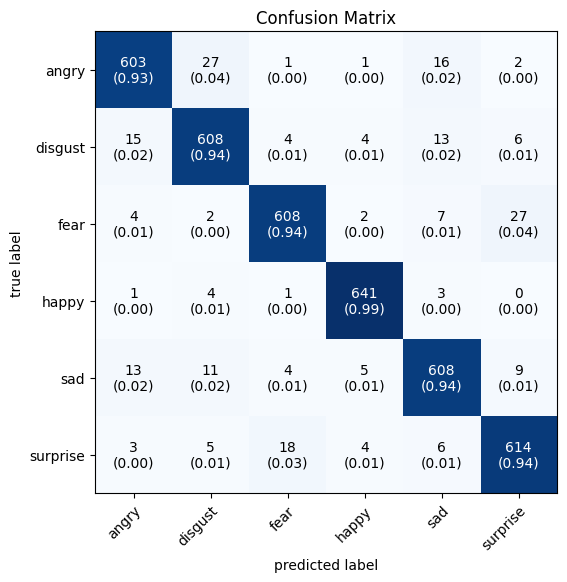

In [36]:
from sklearn.metrics import confusion_matrix, classification_report
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

model_resnet56.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model_resnet56(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

matc = confusion_matrix(y_true, y_pred)
class_names = test_dataset.dataset.classes
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

fig, ax = plot_confusion_matrix(conf_mat=matc,
                                class_names=class_names,
                                figsize=(6,6),
                                cmap="Blues",
                                show_normed=True)
plt.title("Confusion Matrix")
plt.show()


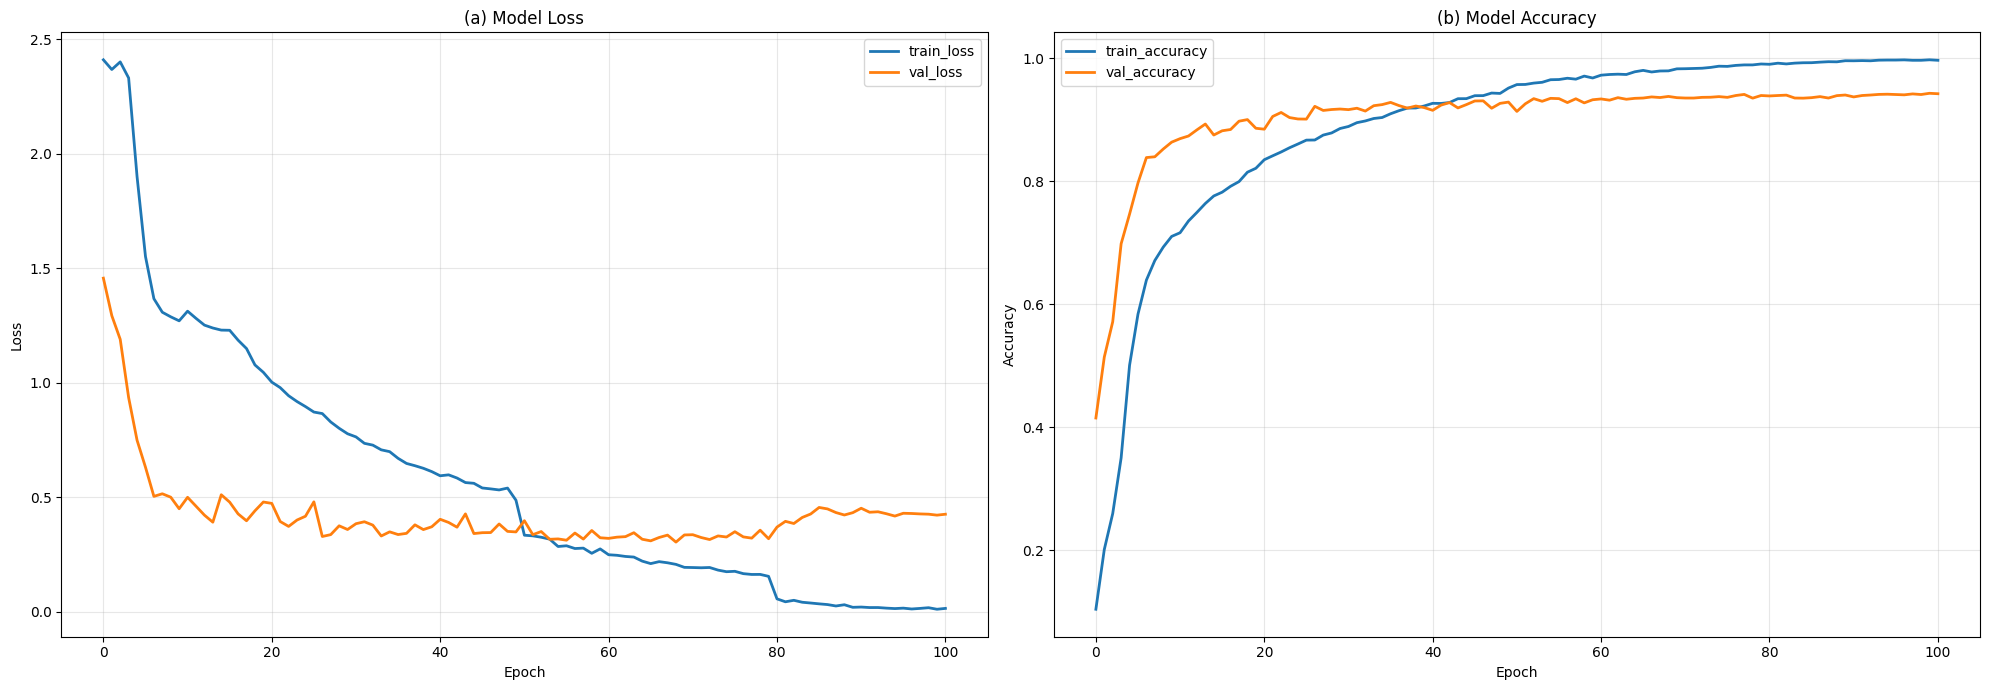

In [ ]:
import re
import matplotlib.pyplot as plt

# ==========================================================
# 📂 PEGA AQUÍ EL LOG COMPLETO TAL CUAL
# ==========================================================
log_text = r"""
Epoch 0/101: 100%|██████████| 195/195 [02:24<00:00,  1.35it/s]
[BEST] epoch=0 val_acc=0.4149
Epoch 0: train_cost=2.410152, val_cost=1.456681, train_acc=0.1037, val_acc=0.4149, lr=0.002129
Epoch 1/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]
[BEST] epoch=1 val_acc=0.5141
Epoch 1: train_cost=2.367781, val_cost=1.292964, train_acc=0.2010, val_acc=0.5141, lr=0.002514
Epoch 2/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=2 val_acc=0.5715
Epoch 2: train_cost=2.401017, val_cost=1.189503, train_acc=0.2594, val_acc=0.5715, lr=0.003152
Epoch 3/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=3 val_acc=0.6985
Epoch 3: train_cost=2.330766, val_cost=0.934984, train_acc=0.3501, val_acc=0.6985, lr=0.004035
Epoch 4/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=4 val_acc=0.7467
Epoch 4: train_cost=1.900023, val_cost=0.748846, train_acc=0.5007, val_acc=0.7467, lr=0.005155
Epoch 5/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=5 val_acc=0.7974
Epoch 5: train_cost=1.551213, val_cost=0.631076, train_acc=0.5839, val_acc=0.7974, lr=0.006498
Epoch 6/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=6 val_acc=0.8387
Epoch 6: train_cost=1.366914, val_cost=0.503676, train_acc=0.6393, val_acc=0.8387, lr=0.008050
Epoch 7/101: 100%|██████████| 195/195 [02:27<00:00,  1.33it/s]
[BEST] epoch=7 val_acc=0.8400
Epoch 7: train_cost=1.307812, val_cost=0.515039, train_acc=0.6712, val_acc=0.8400, lr=0.009796
Epoch 8/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=8 val_acc=0.8526
Epoch 8: train_cost=1.287765, val_cost=0.500111, train_acc=0.6930, val_acc=0.8526, lr=0.011716
Epoch 9/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=9 val_acc=0.8638
Epoch 9: train_cost=1.270253, val_cost=0.449649, train_acc=0.7104, val_acc=0.8638, lr=0.013789
Epoch 10/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=10 val_acc=0.8695
Epoch 10: train_cost=1.312434, val_cost=0.499602, train_acc=0.7164, val_acc=0.8695, lr=0.015993
Epoch 11/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=11 val_acc=0.8738
Epoch 11: train_cost=1.281062, val_cost=0.460805, train_acc=0.7355, val_acc=0.8738, lr=0.018305
Epoch 12/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=12 val_acc=0.8838
Epoch 12: train_cost=1.251583, val_cost=0.421787, train_acc=0.7495, val_acc=0.8838, lr=0.020700
Epoch 13/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=13 val_acc=0.8933
Epoch 13: train_cost=1.238918, val_cost=0.390960, train_acc=0.7640, val_acc=0.8933, lr=0.023151
Epoch 14/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 14: train_cost=1.229755, val_cost=0.510737, train_acc=0.7762, val_acc=0.8754, lr=0.025633
Epoch 15/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 15: train_cost=1.228982, val_cost=0.478464, train_acc=0.7824, val_acc=0.8823, lr=0.028119
Epoch 16/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 16: train_cost=1.185733, val_cost=0.427197, train_acc=0.7920, val_acc=0.8844, lr=0.030582
Epoch 17/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=17 val_acc=0.8979
Epoch 17: train_cost=1.149152, val_cost=0.397054, train_acc=0.7996, val_acc=0.8979, lr=0.032996
Epoch 18/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=18 val_acc=0.9005
Epoch 18: train_cost=1.077646, val_cost=0.440618, train_acc=0.8149, val_acc=0.9005, lr=0.035335
Epoch 19/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 19: train_cost=1.045367, val_cost=0.479029, train_acc=0.8213, val_acc=0.8864, lr=0.037574
Epoch 20/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 20: train_cost=1.002581, val_cost=0.473042, train_acc=0.8352, val_acc=0.8849, lr=0.039688
Epoch 21/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=21 val_acc=0.9056
Epoch 21: train_cost=0.978490, val_cost=0.393927, train_acc=0.8416, val_acc=0.9056, lr=0.041655
Epoch 22/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=22 val_acc=0.9121
Epoch 22: train_cost=0.943109, val_cost=0.372485, train_acc=0.8478, val_acc=0.9121, lr=0.043454
Epoch 23/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 23: train_cost=0.917710, val_cost=0.400346, train_acc=0.8547, val_acc=0.9038, lr=0.045066
Epoch 24/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 24: train_cost=0.895775, val_cost=0.416954, train_acc=0.8608, val_acc=0.9015, lr=0.046472
Epoch 25/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 25: train_cost=0.871898, val_cost=0.479835, train_acc=0.8671, val_acc=0.9013, lr=0.047659
Epoch 26/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=26 val_acc=0.9221
Epoch 26: train_cost=0.865265, val_cost=0.328437, train_acc=0.8673, val_acc=0.9221, lr=0.048613
Epoch 27/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 27: train_cost=0.828597, val_cost=0.336607, train_acc=0.8753, val_acc=0.9154, lr=0.049324
Epoch 28/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 28: train_cost=0.801024, val_cost=0.375117, train_acc=0.8788, val_acc=0.9169, lr=0.049784
Epoch 29/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 29: train_cost=0.777129, val_cost=0.358977, train_acc=0.8860, val_acc=0.9177, lr=0.049989
Epoch 30/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 30: train_cost=0.763407, val_cost=0.384294, train_acc=0.8893, val_acc=0.9167, lr=0.049988
Epoch 31/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 31: train_cost=0.735318, val_cost=0.392852, train_acc=0.8955, val_acc=0.9190, lr=0.049928
Epoch 32/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 32: train_cost=0.727442, val_cost=0.378110, train_acc=0.8983, val_acc=0.9144, lr=0.049820
Epoch 33/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=33 val_acc=0.9231
Epoch 33: train_cost=0.706907, val_cost=0.330660, train_acc=0.9023, val_acc=0.9231, lr=0.049662
Epoch 34/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=34 val_acc=0.9249
Epoch 34: train_cost=0.698939, val_cost=0.348780, train_acc=0.9039, val_acc=0.9249, lr=0.049456
Epoch 35/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=35 val_acc=0.9285
Epoch 35: train_cost=0.669798, val_cost=0.336931, train_acc=0.9100, val_acc=0.9285, lr=0.049201
Epoch 36/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 36: train_cost=0.647506, val_cost=0.342188, train_acc=0.9150, val_acc=0.9233, lr=0.048899
Epoch 37/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 37: train_cost=0.637571, val_cost=0.379369, train_acc=0.9192, val_acc=0.9192, lr=0.048549
Epoch 38/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 38: train_cost=0.626318, val_cost=0.358649, train_acc=0.9194, val_acc=0.9226, lr=0.048153
Epoch 39/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 39: train_cost=0.611801, val_cost=0.370902, train_acc=0.9227, val_acc=0.9200, lr=0.047711
Epoch 40/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 40: train_cost=0.593585, val_cost=0.403599, train_acc=0.9270, val_acc=0.9156, lr=0.047225
Epoch 41/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 41: train_cost=0.597686, val_cost=0.389828, train_acc=0.9268, val_acc=0.9241, lr=0.046694
Epoch 42/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 42: train_cost=0.583768, val_cost=0.369045, train_acc=0.9283, val_acc=0.9282, lr=0.046121
Epoch 43/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 43: train_cost=0.563971, val_cost=0.427178, train_acc=0.9345, val_acc=0.9195, lr=0.045506
Epoch 44/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 44: train_cost=0.560764, val_cost=0.341265, train_acc=0.9346, val_acc=0.9249, lr=0.044850
Epoch 45/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=45 val_acc=0.9308
Epoch 45: train_cost=0.540339, val_cost=0.345065, train_acc=0.9394, val_acc=0.9308, lr=0.044156
Epoch 46/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=46 val_acc=0.9310
Epoch 46: train_cost=0.536377, val_cost=0.345644, train_acc=0.9395, val_acc=0.9310, lr=0.043423
Epoch 47/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 47: train_cost=0.531783, val_cost=0.383147, train_acc=0.9437, val_acc=0.9190, lr=0.042654
Epoch 48/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 48: train_cost=0.539897, val_cost=0.350758, train_acc=0.9431, val_acc=0.9269, lr=0.041851
Epoch 49/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 49: train_cost=0.486819, val_cost=0.348461, train_acc=0.9518, val_acc=0.9290, lr=0.041014
Epoch 50/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 50: train_cost=0.334033, val_cost=0.397351, train_acc=0.9575, val_acc=0.9138, lr=0.040145
Epoch 51/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 51: train_cost=0.331316, val_cost=0.336403, train_acc=0.9577, val_acc=0.9262, lr=0.039247
Epoch 52/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=52 val_acc=0.9346
Epoch 52: train_cost=0.325160, val_cost=0.350074, train_acc=0.9599, val_acc=0.9346, lr=0.038320
Epoch 53/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 53: train_cost=0.316886, val_cost=0.316225, train_acc=0.9612, val_acc=0.9303, lr=0.037367
Epoch 54/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=54 val_acc=0.9351
Epoch 54: train_cost=0.284733, val_cost=0.317867, train_acc=0.9654, val_acc=0.9351, lr=0.036390
Epoch 55/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 55: train_cost=0.287917, val_cost=0.312240, train_acc=0.9657, val_acc=0.9346, lr=0.035390
Epoch 56/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 56: train_cost=0.275905, val_cost=0.343526, train_acc=0.9678, val_acc=0.9282, lr=0.034370
Epoch 57/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 57: train_cost=0.277663, val_cost=0.317244, train_acc=0.9663, val_acc=0.9344, lr=0.033331
Epoch 58/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 58: train_cost=0.255051, val_cost=0.354683, train_acc=0.9713, val_acc=0.9277, lr=0.032276
Epoch 59/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 59: train_cost=0.274288, val_cost=0.322936, train_acc=0.9682, val_acc=0.9328, lr=0.031206
Epoch 60/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 60: train_cost=0.248771, val_cost=0.320241, train_acc=0.9728, val_acc=0.9341, lr=0.030124
Epoch 61/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 61: train_cost=0.246350, val_cost=0.325587, train_acc=0.9739, val_acc=0.9321, lr=0.029032
Epoch 62/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=62 val_acc=0.9362
Epoch 62: train_cost=0.241312, val_cost=0.327761, train_acc=0.9744, val_acc=0.9362, lr=0.027932
Epoch 63/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 63: train_cost=0.238637, val_cost=0.344971, train_acc=0.9739, val_acc=0.9336, lr=0.026827
Epoch 64/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 64: train_cost=0.220812, val_cost=0.316390, train_acc=0.9783, val_acc=0.9351, lr=0.025717
Epoch 65/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 65: train_cost=0.210074, val_cost=0.309440, train_acc=0.9806, val_acc=0.9356, lr=0.024607
Epoch 66/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=66 val_acc=0.9374
Epoch 66: train_cost=0.218624, val_cost=0.324082, train_acc=0.9780, val_acc=0.9374, lr=0.023497
Epoch 67/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 67: train_cost=0.213658, val_cost=0.334531, train_acc=0.9796, val_acc=0.9364, lr=0.022390
Epoch 68/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=68 val_acc=0.9382
Epoch 68: train_cost=0.206700, val_cost=0.304015, train_acc=0.9798, val_acc=0.9382, lr=0.021288
Epoch 69/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 69: train_cost=0.193690, val_cost=0.335216, train_acc=0.9831, val_acc=0.9362, lr=0.020193
Epoch 70/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 70: train_cost=0.192883, val_cost=0.336258, train_acc=0.9833, val_acc=0.9356, lr=0.019108
Epoch 71/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 71: train_cost=0.191864, val_cost=0.323954, train_acc=0.9837, val_acc=0.9356, lr=0.018035
Epoch 72/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 72: train_cost=0.193086, val_cost=0.315138, train_acc=0.9841, val_acc=0.9367, lr=0.016975
Epoch 73/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 73: train_cost=0.181656, val_cost=0.330936, train_acc=0.9854, val_acc=0.9369, lr=0.015932
Epoch 74/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 74: train_cost=0.174710, val_cost=0.326171, train_acc=0.9874, val_acc=0.9379, lr=0.014906
Epoch 75/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 75: train_cost=0.176413, val_cost=0.349410, train_acc=0.9871, val_acc=0.9367, lr=0.013900
Epoch 76/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=76 val_acc=0.9397
Epoch 76: train_cost=0.166182, val_cost=0.326702, train_acc=0.9887, val_acc=0.9397, lr=0.012916
Epoch 77/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=77 val_acc=0.9415
Epoch 77: train_cost=0.162676, val_cost=0.321294, train_acc=0.9895, val_acc=0.9415, lr=0.011956
Epoch 78/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 78: train_cost=0.162933, val_cost=0.356062, train_acc=0.9895, val_acc=0.9354, lr=0.011021
Epoch 79/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 79: train_cost=0.154469, val_cost=0.318786, train_acc=0.9910, val_acc=0.9397, lr=0.010114
Epoch 80/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 80: train_cost=0.056130, val_cost=0.369543, train_acc=0.9905, val_acc=0.9390, lr=0.009237
Epoch 81/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 81: train_cost=0.043349, val_cost=0.394624, train_acc=0.9923, val_acc=0.9397, lr=0.008391
Epoch 82/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 82: train_cost=0.049792, val_cost=0.385167, train_acc=0.9911, val_acc=0.9403, lr=0.007577
Epoch 83/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 83: train_cost=0.041324, val_cost=0.411582, train_acc=0.9924, val_acc=0.9356, lr=0.006798
Epoch 84/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 84: train_cost=0.037938, val_cost=0.426709, train_acc=0.9930, val_acc=0.9354, lr=0.006055
Epoch 85/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 85: train_cost=0.034320, val_cost=0.455266, train_acc=0.9931, val_acc=0.9362, lr=0.005349
Epoch 86/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 86: train_cost=0.031182, val_cost=0.448908, train_acc=0.9940, val_acc=0.9379, lr=0.004682
Epoch 87/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 87: train_cost=0.025004, val_cost=0.433012, train_acc=0.9947, val_acc=0.9356, lr=0.004055
Epoch 88/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 88: train_cost=0.030414, val_cost=0.422358, train_acc=0.9945, val_acc=0.9395, lr=0.003470
Epoch 89/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 89: train_cost=0.019199, val_cost=0.432431, train_acc=0.9963, val_acc=0.9405, lr=0.002927
Epoch 90/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 90: train_cost=0.020354, val_cost=0.451838, train_acc=0.9962, val_acc=0.9374, lr=0.002427
Epoch 91/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 91: train_cost=0.018140, val_cost=0.434370, train_acc=0.9965, val_acc=0.9397, lr=0.001972
Epoch 92/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 92: train_cost=0.018221, val_cost=0.436430, train_acc=0.9962, val_acc=0.9405, lr=0.001563
Epoch 93/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
Epoch 93: train_cost=0.015611, val_cost=0.427767, train_acc=0.9972, val_acc=0.9415, lr=0.001200
Epoch 94/101: 100%|██████████| 195/195 [02:26<00:00,  1.33it/s]
[BEST] epoch=94 val_acc=0.9418
Epoch 94: train_cost=0.013685, val_cost=0.417648, train_acc=0.9974, val_acc=0.9418, lr=0.000884
Epoch 95/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]
Epoch 95: train_cost=0.015569, val_cost=0.429887, train_acc=0.9974, val_acc=0.9413, lr=0.000615
Epoch 96/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]
Epoch 96: train_cost=0.011935, val_cost=0.428920, train_acc=0.9977, val_acc=0.9408, lr=0.000395
Epoch 97/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]
[BEST] epoch=97 val_acc=0.9423
Epoch 97: train_cost=0.014435, val_cost=0.427030, train_acc=0.9970, val_acc=0.9423, lr=0.000223
Epoch 98/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]
Epoch 98: train_cost=0.017463, val_cost=0.425873, train_acc=0.9970, val_acc=0.9413, lr=0.000100
Epoch 99/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]
[BEST] epoch=99 val_acc=0.9433
Epoch 99: train_cost=0.010734, val_cost=0.421713, train_acc=0.9978, val_acc=0.9433, lr=0.000026
Epoch 100/101: 100%|██████████| 195/195 [02:25<00:00,  1.34it/s]
Epoch 100: train_cost=0.014453, val_cost=0.425708, train_acc=0.9970, val_acc=0.9426, lr=0.000002
"""

pattern = re.compile(
    r"Epoch\s+(\d+):\s+train_cost=([\d\.]+),\s+val_cost=([\d\.]+),\s+train_acc=([\d\.]+),\s+val_acc=([\d\.]+),\s+lr=([\d\.]+)"
)

epochs = []
train_loss = []
val_loss = []
train_acc = []
val_acc = []
learning_rates = []

for match in pattern.finditer(log_text):
    epochs.append(int(match.group(1)))
    train_loss.append(float(match.group(2)))
    val_loss.append(float(match.group(3)))
    train_acc.append(float(match.group(4)))
    val_acc.append(float(match.group(5)))
    learning_rates.append(float(match.group(6)))

plt.style.use("default")
fig, axs = plt.subplots(1, 2, figsize=(20, 7))
axs[0].plot(epochs, train_loss, label='train_loss', linewidth=2)
axs[0].plot(epochs, val_loss, label='val_loss', linewidth=2)

axs[0].set_title('(a) Model Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].plot(epochs, train_acc, label='train_accuracy', linewidth=2)
axs[1].plot(epochs, val_acc, label='val_accuracy', linewidth=2)

axs[1].set_title('(b) Model Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

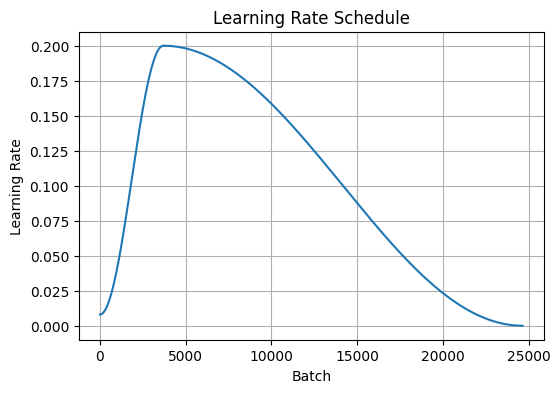

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(lrs)
plt.xlabel('Batch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True)
plt.show()


In [23]:
class_names = test_loader.dataset.dataset.classes
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']


In [ ]:
model=model_resnet56

Extrayendo linear embeddings: 100%|██████████| 25/25 [00:11<00:00,  2.09it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Embeddings conv: torch.Size([3900, 8192]), lineal: torch.Size([3900, 512])
Aplicando t-SNE... esto puede tardar unos minutos ⏳


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


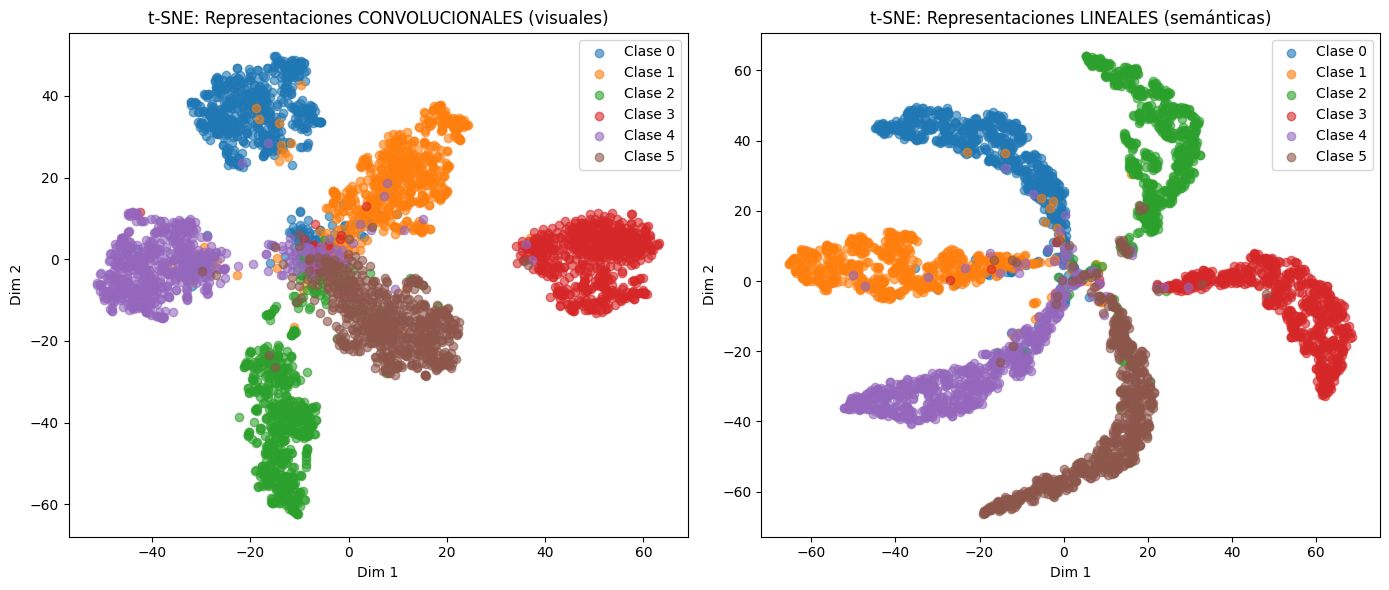

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


def extract_embeddings_resnet56(model, loader, device, layer_type='conv'):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Extrayendo {layer_type} embeddings"):
            x = x.to(device)

            #Embeddings CONVOLUCIONALES
            if layer_type == 'conv':
                y_conv = F.relu(model.bn1(model.conv1(x)))
                y_conv = model.block1(y_conv)
                y_conv = model.block2(y_conv)
                y_conv = model.block3(y_conv)
                y_conv = F.silu(model.f_e(y_conv))
                feats = torch.flatten(y_conv, 1)  # (batch, features)

            #Embeddings LINEALES (semánticos)
            elif layer_type == 'linear':
                y_conv = F.relu(model.bn1(model.conv1(x)))
                y_conv = model.block1(y_conv)
                y_conv = model.block2(y_conv)
                y_conv = model.block3(y_conv)
                y_conv = F.silu(model.f_e(y_conv))
                y_flat = model.flatten(y_conv)

                y_dense1 = F.relu(model.bn2(model.dense1(y_flat)))
                feats =y_dense1  

            embeddings.append(feats.cpu())
            labels.append(y)

    return torch.cat(embeddings), torch.cat(labels)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

conv_embeds, conv_labels = extract_embeddings_resnet56(model_resnet56, test_loader, device, layer_type='conv')
lin_embeds, lin_labels   = extract_embeddings_resnet56(model_resnet56, test_loader, device, layer_type='linear')

print(f"Embeddings conv: {conv_embeds.shape}, lineal: {lin_embeds.shape}")

print("Aplicando t-SNE... esto puede tardar unos minutos ⏳")

tsne_conv = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_lin  = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)

conv_tsne = tsne_conv.fit_transform(conv_embeds)
lin_tsne  = tsne_lin.fit_transform(lin_embeds)

plt.figure(figsize=(14,6))
num_classes = len(torch.unique(conv_labels))

# --- Convolucional ---
plt.subplot(1,2,1)
for c in range(num_classes):
    mask = conv_labels == c
    plt.scatter(conv_tsne[mask,0], conv_tsne[mask,1], alpha=0.6, label=f"Clase {c}")
plt.title("t-SNE: Representaciones CONVOLUCIONALES (visuales)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.legend()

# --- Lineal ---
plt.subplot(1,2,2)
for c in range(num_classes):
    mask = lin_labels == c
    plt.scatter(lin_tsne[mask,0], lin_tsne[mask,1], alpha=0.6, label=f"Clase {c}")
plt.title("t-SNE: Representaciones LINEALES (semánticas)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.legend()

plt.tight_layout()
plt.show()
